# Исследование объявлений о продаже квартир 

В распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

# Оглавление:

**1. [Загрузка данных](#open_data)** 

**2. [Предобработка данных](#data_processing)**

2.1 [Обработка аномалий](#anomaly_find)

2.2 [Обработка пропусков](#fight_with_nan)

2.3 [Обработка неявных дубликатов](#dublicates_found)

2.4 [Изменение типа данных](#change_type)

**3. [Добавление новых столбцов](#new_columns)**

**4. [Исследовательский анализ данных](#analyze)**

4.1 [Описание наблюдений по основным параметрам](#params)

4.2 [Изучение скорости продажи квартир](#selling_speed)

4.3 [Определение факторов, влияющих на стоимость объекта](#cost_total_params)

4.4 [Расчет средней цены квадратного метра в 10 населенных пунктах, с самым большим числом объявлений](#cost_per_meter)

4.5 [Изучение влияния удаленности от центра на стоимость жилья в Санкт-Петербурге](#centre_cost)

**5. [Общий вывод](#conclusion)**

In [ ]:
# Импортируем библиотеку pandas для работы с данными
import pandas as pd 
# Даты
import datetime as dt

# понадобится для построения графиков
import matplotlib.pyplot as plt
# Чтобы графики строились без вывода избыточной информации, импортурем библиотеку "warnings"
import warnings


<a name="open_data"></a>
## Откройте файл с данными и изучите общую информацию 

In [1]:
# Загружаем данные по недвижимости. Указываем, что разделитель - '\t'
try:
    data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t') 
except:
    print('Не удалось загрузить данные. Проверьте указанное расположение!')

In [2]:
# Выведем первые 10 строк, чтобы получить представление о данных
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [3]:
# Выведем информацию о количестве пропусков и типах данных в датасете
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

**Комментарий к полученным данным:**

Количество записей в датасете: 23699.

Присутствуют столбцы со значительным количеством пропусков.

Название столбца "cityCenters_nearest" не соответствует каноничному виду.

Требуется предобработка.

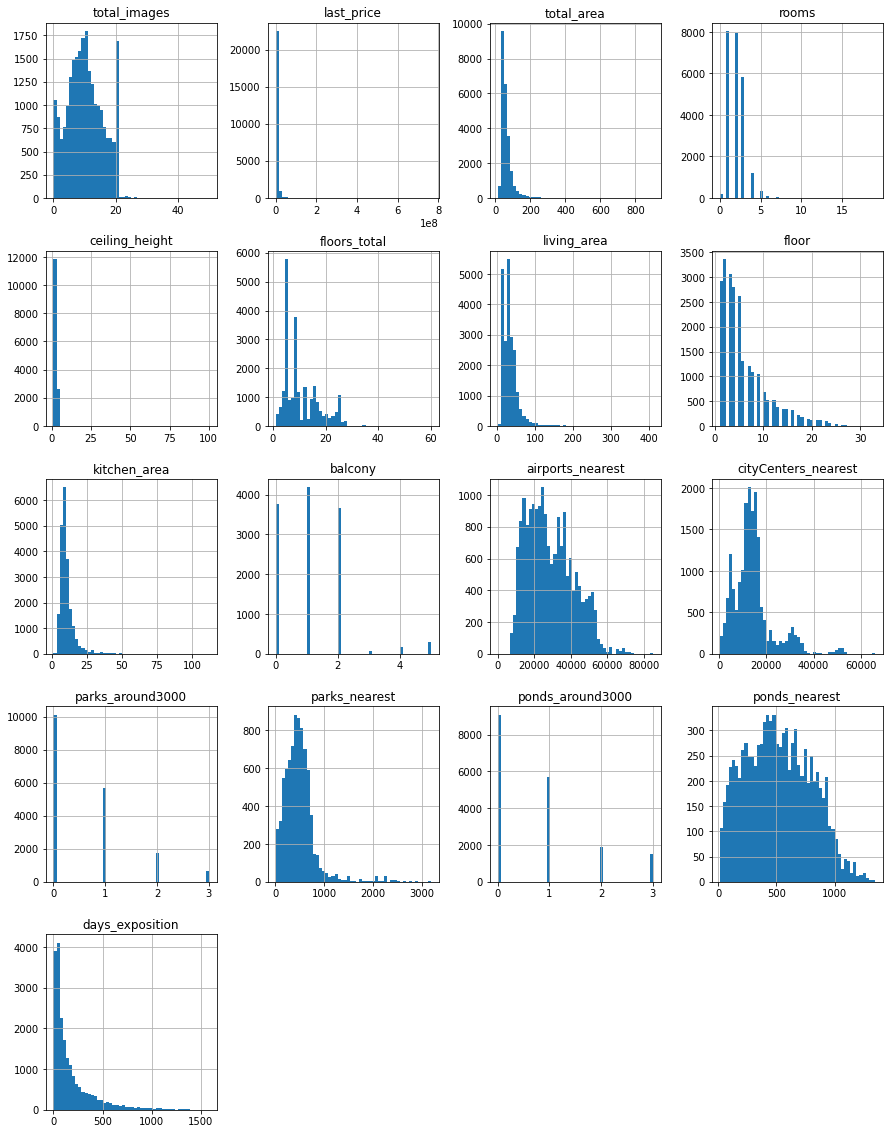

In [4]:
# Поссмотрим общее распределение значений, построив гистограмму по всему датасету
data.hist(figsize=(15, 20),bins=50)

warnings.simplefilter('ignore')

In [5]:
# Подкрепим наглядное отображение распределения данных конкретными числовыми значениями.
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000


**Комментарий к распределению данных:**

Стоит обратить внимание на присутствие *аномально низких значений* в столбцах:
- *rooms* (0 - комнат в объявлении о продаже квартиры)
- *ceiling_height* (Высота потолков в метрах - 1м. По информации из открытых источников высота в жилых комнатах должна быть порядка 2.5м, а для остальных порядка 2м. Значит, значения ниже можно считать аномальными.)
- *living_area* (наблюдаются значения жилой площади порядка 2 метра, хотя по нормам (по информации из открытых источников) должно быть не меньше 14 метров. Однако, учтем, что нормы могли меняться, и будем считать за аномальные - значения меньше 8 метров.
- *airports_nearest* (Нулевые и около нулевые расстояния в метрах до ближайшего аэропорта)

Судя по гистограмме таких значений мало, скорее всего их можно расценивать как выбросы.

Также может сильно отразиться на расчетах присутствие значений, значительно превышающих средние, в столбцах: *last_price*, *total_area*, *rooms*, *ceiling_height*, *floors_total*, *living_area*, *kitchen_area*, *cityCenters_nearest*, *parks_nearest* и *days_exposition*.

Особенно выделяется столбец *ceiling_height* - высота потолков 100 метров выглядит неправдоподобно. 

Судя по распределению значений для остальных столбцов, аномально высоких значений немного, скорее всего при категорировании значений лучшим решением будет выделить их в отдельную группу.

<a name="data_processing"></a>
## Выполните предобработку данных 

In [6]:
# Переименуем столбец cityCenters_nearest, чтобы он был в змеевидной форме, методом rename()
data = data.rename(columns={'cityCenters_nearest':'city_сenters_nearest'})
data.columns

Index(['total_images', 'last_price', 'total_area', 'first_day_exposition',
       'rooms', 'ceiling_height', 'floors_total', 'living_area', 'floor',
       'is_apartment', 'studio', 'open_plan', 'kitchen_area', 'balcony',
       'locality_name', 'airports_nearest', 'city_сenters_nearest',
       'parks_around3000', 'parks_nearest', 'ponds_around3000',
       'ponds_nearest', 'days_exposition'],
      dtype='object')

<a name="anomaly_find"></a>

#### **Обработка аномалий**

Займемся обработкой аномалий, так как аномальные значения могут повлиять на медианы при заполнении пропусков.

Решим вопрос с 0 комнат. Конечно, большинство объявлений, где стоит 0 являются объявлениями про студии.

In [7]:
print(f"Всего объявлений с нулем комнат: {data.query('rooms == 0')['rooms'].count()}, \
из них студии: {data.query('rooms == 0 and studio')['rooms'].count()}")

Всего объявлений с нулем комнат: 197, из них студии: 138


Однако, все-равно логичнее будет заменить 0 на 1. Во-первых, есть объявления, где указано, что помещение - студия, и одновременно с этим количество комнат отлично от нуля; во-вторых, сам вопрос о существовании помещний с нулем комнат похож скорее на вопрос о существовании 0-мерных пространтств.

In [8]:
data.loc[data['rooms']==0,'rooms'] = 1

Займемся столбцом *ceiling_height*. 

По гистограмме с распределением от 0 до 100 видно лишь, что большинство значений находятся около 0. Нужно рассмотреть подробнее и по отдельности промежутки от 0 до 10, и от 10 до 100.

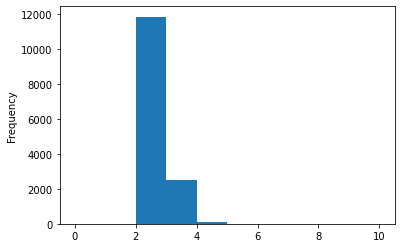

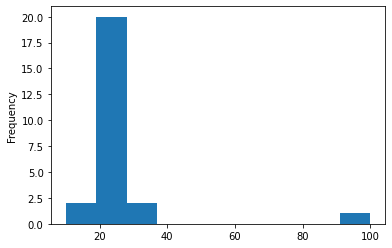

In [9]:


data['ceiling_height'].plot(kind='hist',range=(0,10),bins=10)
plt.show()
data['ceiling_height'].plot(kind='hist',range=(10,100),bins=10)
plt.show()

По первому графику, как и ожидалось, большинство потолков высотой порядка 2 метров, в редких случаях - до пяти.
На втором графике видно, что есть пик в районе 20 метров. Вероятно, в этих значениях опечатка.

Поступим следующим образом: 
1) Значения от 20 до 50 - разделим на 10;
2) Затем все что меньше 2 или больше 5 заменим на медиану.

In [10]:
# Исправим возможные опечатки, разделив аномальные значения на 10
data.loc[(data['ceiling_height'] > 20) & (data['ceiling_height'] < 50),'ceiling_height'] = \
data.loc[(data['ceiling_height'] > 20) & (data['ceiling_height'] < 50),'ceiling_height'] / 10

# Оставшиеся аномалии заменим на медиану
data.loc[(data['ceiling_height'] < 2) | (data['ceiling_height'] > 5),'ceiling_height'] = \
data.loc[(data['ceiling_height'] < 2) | (data['ceiling_height'] > 5),'ceiling_height'].median()

Займемся аномально-малым расстоянием до ближ. аэропорта.

In [11]:
# Посмотрим сколько значений меньше 1000, и каково наименьшее растояние, не считая нуля.

print(f"Количество записей, где аэропорт ближе 1000 метров: {data.query('airports_nearest < 1000 ')['airports_nearest'].count()}; \
самое близкое расстояние, не считая нуля: {data.query('airports_nearest > 0 ')['airports_nearest'].min()}")

Количество записей, где аэропорт ближе 1000 метров: 1; самое близкое расстояние, не считая нуля: 6450.0


Запись оказалась всего одна. Удалим это значение, чтобы потом заполнить его вместе с остальными пропусками.

In [12]:
data.loc[data['airports_nearest']==0,'airports_nearest'] = None 

Перейдем к обработке аномалий в *kitchen_area*.

Хотя и минимальное значение 1.3 метра выглядит неправдоподобно, не стоит исключать возможность специфичной планировки с маленькой угловой кухней. Важным является проверить, что бы размер кухни не превышал общую площадь помещения.

In [13]:
data.query('kitchen_area > total_area').loc[:,['total_area','kitchen_area']]

,total_area,kitchen_area


Обработаем строки где сумма площади кухни и жилой площади больше общей. Вероятно, в таких случаях стоит вычесть из жилой площади площадь кухни. 

In [14]:
# если сумма кухни и жилой больше общей вычитаем из жилой площадь кухни
data.loc[data['kitchen_area'] + data['living_area'] > data['total_area'],'living_area'] \
-= data.query('kitchen_area + living_area > total_area')['kitchen_area']

# если при расчете получилось значение меньше 0, присвоим 0
data.loc[data['living_area'] < 0,'living_area'] = 0


Перейдем к обработке аномалий в *living_area*.

Сначала посмотрим на значения меньше 8 м. При этом, если помещение - апартамент, на величину жилой площади не смотрим.  

In [15]:
# Выберемем *living_area* меньше 8, и методом isna() выберем не апартаменты (в столбце *is_apartment* заполнены только False)
data.loc[:,['total_area', 'living_area','kitchen_area','is_apartment']].query('living_area < 8 and not is_apartment.isna()').sort_values(by='living_area')

,total_area,living_area,kitchen_area,is_apartment


Таких значений не оказалось.

Проверим нет ли значений, где жилая больше общей

In [16]:
data.query('living_area > total_area').loc[:,['total_area','living_area']]

,total_area,living_area


Убедимся, что высокие значения в *total_area* не являются опечаткой, как это было в *ceiling_height*.

Для этого посмотрим, например, каковы цена и количество комнат в этих строках.

In [17]:
# Срез покажет, какова цена и количество комнат в объявлениях про недвижимость с площадью более 300 метров.
data.query('total_area > 300').loc[:, ['total_area','rooms','last_price']].sort_values('total_area', ascending=False)

,total_area,rooms,last_price
19540,900.0,12,420000000.0
12859,631.2,7,140000000.0
3117,631.0,7,140000000.0
15651,618.0,7,300000000.0
5358,590.0,15,65000000.0
...,...,...,...
793,310.0,4,135000000.0
13397,309.7,9,19500000.0
7543,307.8,5,130000000.0
2243,304.0,5,130278280.0


Комнат много, цена большая, значит и высокие значения в *total_area* - не опечатки.

**Вывод по обработке аномалий**

Противоречивые значения были обнаружены и обработаны в столбцах: 
- *room* - больше нет помещений с нулем комнат, минимальное значение - 1
- *ceiling_height* - была обнаружена и исправлена часть значений, вводимых с опечаткой (например, потолок с высотой 25 метров, на самом деле является потолком с высотой 2.5 метра). Затем недопустимо низкие и высокие значения были исправлены на медианное значение.
- *airports_nearest* - было обнаружено единственное значение с нулем, вместо него был проставлен пропуск, чтобы затем заполнить его вместе с остальными пропусками.
- *living_area* и *kitchen_area* - обработаны значения, в которых их сумма превыщала значение в *total_area*

Рекомендации: добавить ограничение для пользователя на вводимые значения (приоритетно для описанных выше столбцов) 

<a name="fight_with_nan"></a>
#### **Обработка пропусков.**

In [18]:
# Посчитаем количество пропущенных значений в каждом столбце
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5543
city_сenters_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Займемся пропусками в столбце *ceiling_height*.

Количество пропусков - 9195 при общем количестве строк 23699. Слишком много, чтобы просто избавиться от них.

Чтобы убедиться, что пропуски носят случайный характер, посмотрим распределение всех значений, где есть пропуски в *ceiling_height*.

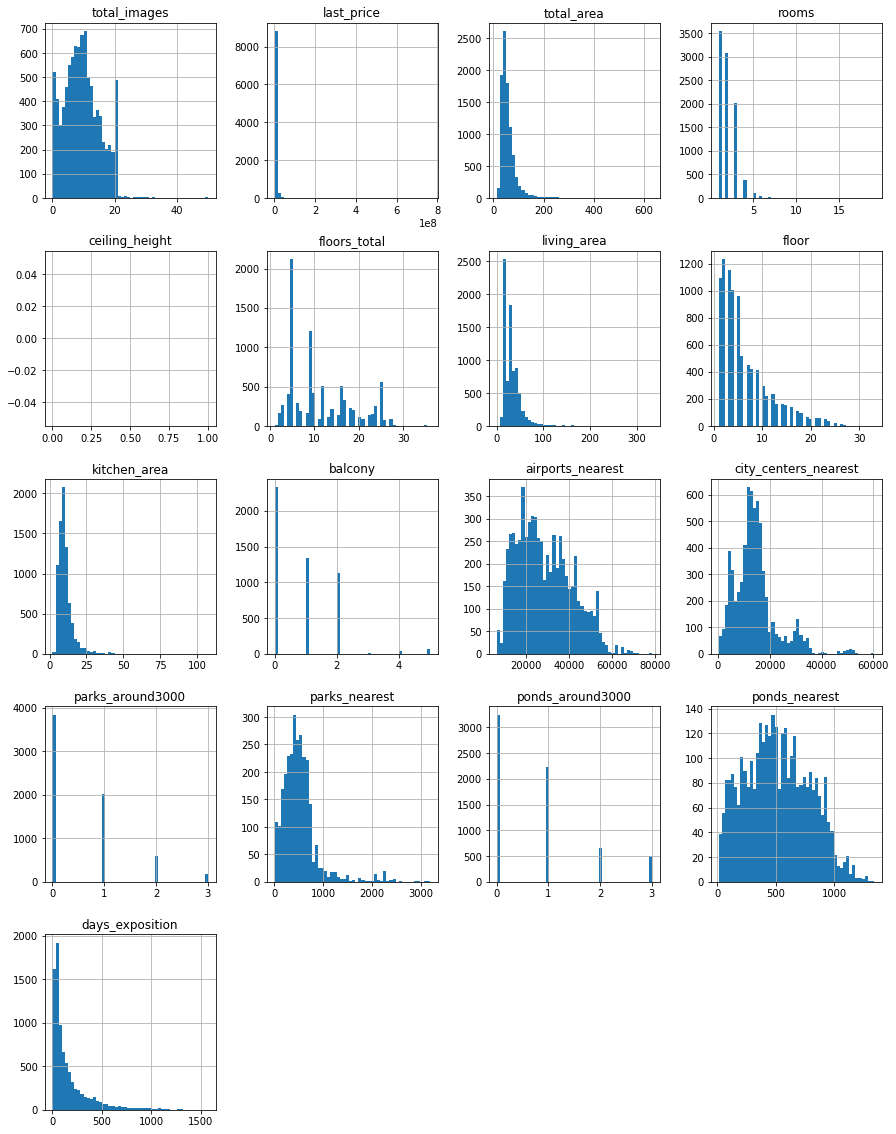

In [19]:
# Построим гистограмму методом hist(), выделив срез с помощью метода query() по пропущенным значениям в "ceiling_height", выделенным методом isna()
data.query('ceiling_height.isna()').hist(figsize=(15, 20),bins=50)
warnings.simplefilter('ignore') # Используем этот метод, чтобы не выводились предупреждения.

Распределение по срезу похоже на общее, поэтому заменим пропуски на медианное значение (среднее не используем из-за присутствия выбросов).

In [20]:
# Сначала посмотрим, каким будет это значение, вычислив медиану.
data['ceiling_height'].median()

2.65

In [21]:
# Значение выглядит правдоподобно, используем его, чтобы заменить пропуски методом fillna()
data['ceiling_height'] = data['ceiling_height'].fillna(data['ceiling_height'].median())

# Сразу убедимся, что пропущенных значений больше нет
data['ceiling_height'].isna().sum()

0

Перейдем к пропускам в столбце *floors_total*.

Их немного, можно было бы отбросить их, но необходимо проверить предположение: возможно, пропущены значения в объявлениях, где в доме всего 1 этаж.

In [22]:
# Для этого посмотрим, какие значения указаны в столбце "floor",
# сделав срез по проущенным значениям в "floors_total" с помощью query()
# и вызвав value_counts() для столбца "floor"

data.query('floors_total.isna()')['floor'].value_counts().head(5)

4     10
6      9
8      8
12     6
9      5
Name: floor, dtype: int64

Предположение не подтвердилось, и уверенности, что указанный этаж совпадает с количеством этажей в доме тоже нет, но так как данных немного, можно заполнить их из столбца *floor*, чтобы со столбцом *total_floor* можно было проводить математические операции.

In [23]:
# Заполним, выделяя нужные срезы с помощью loc[] с пропусками в целевом столбце, и выбирая нужный столбец
data.loc[data['floors_total'].isna(),'floors_total'] = data.loc[data['floors_total'].isna(),'floor']

# Убедимся, что пропусков больше нет
data['floors_total'].isna().sum()

0

Займемся пропусками в столбце *living_area*.

Количество пропусков - 1903 при общем количестве строк 23699. Слишком много, чтобы просто избавиться от них.

Ситуация аналогична с *ceiling_height*. Однако в датасете существует столбец *total_area*, а значит, вероятно, лучше будет рассчитать не одну медиану для *living_area*, а разбить *total_area* на категории, и в соответствии с этим разбиением расчитать несколько медиан по *living_area*, которыми удастся более точно заполнить пропущенные значения. 

Поскольку для столбца *kitchen_area* (в котором 2278 пропусков) размышления аналогичны, заполним пропуски сразу и в нем.

In [24]:
# Для категорий создадим новый столбец. Для разбиения используем метод cut(), указав вручную границы.
# (границы указаны, таким образом, чтобы подробнее разбить участок с основным скоплением значений, и менее подробно оставшееся)
data['total_area_category'] = pd.cut(data['total_area'], bins=[0, 30, 60, 90, 120, 150, 180, 450, 900]) 

# Будем выводить медианы по total_area, living_area и kitchen_area, чтобы проверить, как происходит заполнение
print('total_area_med    living_area_med    kitchen_area_med') 

for category in data['total_area_category'].sort_values().unique(): # цикл будет идти по категориям
    # аналогично поступаем с kitchen_area 
    kitchen_area_median = (data
                           .query('total_area_category == @category and not studio and not kitchen_area.isna()')['kitchen_area']
                           .median()
                          )
    data.loc[(data['kitchen_area'].isna()) & (data['total_area_category'] == category),'kitchen_area'] = kitchen_area_median 
    
    # для каждой категории расчитаем медиану по living_area и заполним ей пропуски
    # query() - срез для фильтрации по категории и значениям без пропусков
    living_area_median = data.query('total_area_category == @category and not living_area.isna()')['living_area'].median()
    # используем срез по loc[], чтобы присвоить новые значения
    # обязательно проверяем через where() не получилась ли медиана *living_area* больше *total_area*
    # если *total_area* меньше рассчитанной медианы, будем присваивать в *living_area* значение из *total_area*
    # если же, *total_area*, как и должно быть, больше, чем медиана по *living_area*, присваиваем значение расчитанной медианы
    data.loc[(data['living_area'].isna()) & (data['total_area_category'] == category),'living_area'] = (
        (data['total_area'] - kitchen_area_median)
        .where(data['total_area'] <= living_area_median, living_area_median )
    )
                                                                                    
    # посчитаем медиану для total_Area
    total_area_med = data.query('total_area_category == @category and not kitchen_area.isna() and not living_area.isna()')['total_area'].median() 
    
    # выводим расчитанные значения
    print(f'{total_area_med:<20} {living_area_median:<20.2f} {kitchen_area_median:.2f}')
    
#data = data.drop(columns='total_area_category') # за ненадобностью удалим столбец с категориями

total_area_med    living_area_med    kitchen_area_med
28.05                16.20                6.00
44.0                 22.90                8.30
71.0                 43.00                10.56
100.0                59.00                14.40
132.0                78.00                17.06
162.1                97.00                19.65
227.0                143.75               23.05
500.0                307.00               45.25


In [25]:
# если сумма кухни и жилой больше общей вычитаем из жилой площадь кухни
data.loc[data['kitchen_area'] + data['living_area'] > data['total_area'],'living_area'] \
-= data.query('kitchen_area + living_area > total_area')['kitchen_area']

# если при расчете получилось значение меньше 0, присвоим 0
data.loc[data['living_area'] < 0,'living_area'] = 0


In [26]:
# Снова проверим нет ли слишком низких значений для total_area
data.loc[:,['total_area', 'living_area','kitchen_area','is_apartment']].query('living_area < 8 and not is_apartment.isna()').sort_values(by='living_area')

,total_area,living_area,kitchen_area,is_apartment
19546,13.0,7.0,6.0,False


Одно значение - не критично.

In [27]:
# Проверим отсутствие пропусков: срез по "living_area" "kitchen_area",затем суммируем пропуски, найденные с помощью isna()
data.loc[:,['living_area','kitchen_area']].isna().sum()

living_area     0
kitchen_area    0
dtype: int64

Перейдем к пропускам в столбце *is_apartment*.

При вызове метода info() в начале исследования можно увидеть, что столбец имеет тип отличный от *bool*.

Вероятно, символами обозначено, что предложение не апартамент, иначе просто стоит пропуск (там, где апартамент).

In [28]:
data.query('not is_apartment.isna()')['is_apartment']

11       False
25       False
29       False
36       False
41       False
         ...  
23665    False
23667    False
23671    False
23678    False
23682    False
Name: is_apartment, Length: 2775, dtype: object

*False* - написано там, где не апартаменты, значит в обратном случае, то есть там где пропуски, должно стоять *True*

Вероятно, лучше сразу поменять тип данных.


Возможно, еще стоит уточнить точно ли *False* означает "не апартамент", потому что если апартамент - жилье, где нельзя прописаться, то таких объявлений скорее всего должно быть меньше, а не значительно больше.

In [29]:
# Присвоим столбцу результат выполнения isna(), там где было написано false, останется false, иначе будет true
data['is_apartment'] = data['is_apartment'].isna()

# Убедимся, что пропусков больше нет
data['is_apartment'].isna().sum()

0

Перейдем к пропускам в столбцах:
- *balcony* - вероятно, пропукски означают отсутствие балконов;
- *days_exposition*  - пропуски могут означать, что объявление снято в тот же день или не выложено по каким-то причинам.

Заполним пропуски нулями.

Но сначала проверим случайны ли пропуски в *days_exposition*. Посмотрим как они распределены во времени. 

Для этого сначала придется обработать first_day_exposition, чтобы достать оттуда года

Помянеяем тип в столбце *first_day_exposition*.

In [30]:
# Перезапишем столбец, вызвав метод to_datetime(), чтобы изменить тип данных, предварительно указав нужный формат
data['first_day_exposition'] = pd.to_datetime(
    data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S'
)

Добавим столбцы с отображением месяца и года публикации объявления.

In [31]:
data['month_exposition'] = pd.DatetimeIndex(data['first_day_exposition']).month

data['year_exposition'] = pd.DatetimeIndex(data['first_day_exposition']).year

Теперь посмотрим распределение пропусков в *days_exposition* по годам и месяцам, для этого посчитаем долю пропусков от общего количества записей, агрегировав данные по годам и месяцам.

In [32]:
round(data.query('days_exposition.isna()').groupby(['year_exposition','month_exposition'])['total_area'].count() \
/ data.groupby(['year_exposition','month_exposition'])['total_area'].count(), 2)

year_exposition  month_exposition
2014             11                  0.15
                 12                  0.13
2015             1                   0.17
                 2                   0.06
                 3                   0.05
                 4                   0.04
                 5                   0.06
                 6                   0.07
                 7                    NaN
                 8                   0.12
                 9                   0.10
                 10                  0.03
                 11                  0.05
                 12                  0.02
2016             1                   0.01
                 2                   0.03
                 3                   0.03
                 4                   0.01
                 5                   0.03
                 6                   0.01
                 7                   0.01
                 8                   0.08
                 9                   0.04


Действительно, c декабря 2018 начинает поразительно расти доля пропусков, это не случайность.
Значит заполнять пропуски нельзя.

In [33]:
# код ревьюера


data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')
data['first_day_year'] = data['first_day_exposition'].dt.year
data[data['days_exposition'].isnull()].pivot_table(columns = 'first_day_year', values = 'total_area', aggfunc = 'count')

first_day_year,2014,2015,2016,2017,2018,2019
total_area,18,70,67,271,959,1796


In [34]:
# Заполним нулями пропуски только в столбце *balcony*
data.loc[data['balcony'].isna(), 'balcony'] = 0  
        
# Сразу убедимся, что пропусков больше нет
data['balcony'].isna().sum()

0

Перейдем к пропускам в столбце: *locality_name*.

In [35]:
# срез по пустым значениям в locality_name, выбор столбца locality_name и присвоение ему 'не указано'
data = data.dropna(subset=['locality_name'])

# Сразу убедимся, что пропусков больше нет
data['locality_name'].isna().sum()

0

Перейдем к столбцам: *parks_around3000*, *ponds_around3000* и *airports_nearest*, *city_centers_nearest*, *parks_nearest*, *ponds_nearest*.

Вероятно, у программного обеспчения, с помощью которого были автоматически собраны эти данные, существует лимит, в пределах которого следует осуществлять поиск. Если он превышен, то поиск приостанавливается, и в данных образуется пропуск.

Сразу убедимся, что пропуски в *parks_nearest* и *ponds_nearest* совпадают с пропусками в *parks_around3000* и *ponds_around3000*. 

In [36]:
# Сделаем срез с помощью query() для проверки предположения.
data.query('(not parks_nearest.isna() and parks_around3000.isna()) or (not ponds_nearest.isna() and ponds_around3000.isna())')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,city_сenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,total_area_category,month_exposition,year_exposition,first_day_year


Пропуски совпадают, значит заполнить *parks_around3000* и *ponds_around3000* по *parks_nearest* и *ponds_nearest* не получиться.

Оставим все столбцы без, изменений, так как логичную замену предложить нельзя.

<a name='duplicates_found'></a>
#### **Обработка неявных дубликатов**

In [37]:
# Сначала заменим букву Ё на Е
data['locality_name'] = data['locality_name'].str.replace('ё', 'е')

# Вывыдем уникальные значения в 'locality_name', предварительно остортировав. 
data['locality_name'].sort_values().unique()

array(['Бокситогорск', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Высоцк', 'Гатчина', 'Зеленогорск', 'Ивангород', 'Каменногорск',
       'Кингисепп', 'Кириши', 'Кировск', 'Колпино', 'Коммунар',
       'Красное Село', 'Кронштадт', 'Кудрово', 'Лодейное Поле',
       'Ломоносов', 'Луга', 'Любань', 'Мурино', 'Никольское',
       'Новая Ладога', 'Отрадное', 'Павловск', 'Петергоф', 'Пикалево',
       'Подпорожье', 'Приморск', 'Приозерск', 'Пушкин', 'Санкт-Петербург',
       'Светогорск', 'Сертолово', 'Сестрорецк', 'Сланцы', 'Сосновый Бор',
       'Сясьстрой', 'Тихвин', 'Тосно', 'Шлиссельбург',
       'городской поселок Большая Ижора', 'городской поселок Будогощь',
       'городской поселок Виллози', 'городской поселок Лесогорский',
       'городской поселок Мга', 'городской поселок Назия',
       'городской поселок Новоселье', 'городской поселок Павлово',
       'городской поселок Рощино', 'городской поселок Свирьстрой',
       'городской поселок Советский', 'городской поселок Фед

Поскольку в рамках исследования важно знание, что каждое объявление относится к опреленной географической точке, уточнениями, чем именно является географическая точка, можно пренебречь. По крайней мере в рамках исследования не требуется сравнивать что-либо в зависимости от типа населенного пункта. 

In [38]:
# Воспользуемся replace(), чтобы избавиться от всех названий типов населенных пунктов
data['locality_name'] = (data['locality_name'].replace(['городской ',
                                                        'коттеджный ',
                                                        'городского типа ',
                                                        'садоводческое некоммерческое товарищество ',
                                                        'станции ',
                                                        'при железнодорожной ',
                                                        'садовое товарищество ',
                                                        'село ',
                                                        'деревня ',
                                                        'поселок '
                                                       ], '', regex=True)
                        )

data['locality_name'].sort_values().unique()

array(['Агалатово', 'Александровская', 'Алексеевка', 'Аннино', 'Аро',
       'Барышево', 'Батово', 'Бегуницы', 'Белогорка', 'Белоостров',
       'Бокситогорск', 'Большая Вруда', 'Большая Ижора',
       'Большая Пустомержа', 'Большие Колпаны', 'Большое Рейзино',
       'Большой Сабск', 'Бор', 'Борисова Грива', 'Бугры', 'Будогощь',
       'Ваганово', 'Важины', 'Вартемяги', 'Вахнова Кара', 'Вещево',
       'Виллози', 'Вознесенье', 'Возрождение', 'Войсковицы', 'Войскорово',
       'Володарское', 'Волосово', 'Волхов', 'Всеволожск', 'Выборг',
       'Вырица', 'Выскатка', 'Высокоключевой', 'Высоцк', 'Гаврилово',
       'Гарболово', 'Гатчина', 'Гладкое', 'Глажево', 'Глебычево',
       'Глинка', 'Гончарово', 'Горбунки', 'Гостилицы', 'Громово',
       'Дзержинского', 'Дружная Горка', 'Дружноселье', 'Дубровка',
       'Елизаветино', 'Ефимовский', 'Жилгородок', 'Жилпоселок', 'Житково',
       'Заводской', 'Заклинье', 'Заневка', 'Запорожское', 'Зеленогорск',
       'Зимитицы', 'Ивангород', 'Извара'

**Вывод по обработке неявных дубликатов в locality_name:**

Удаление неявных дубликатов позволило избавиться от вавилонского семантического разрыва, когда одно и то же записано по-разному. Теперь можно с большей уверенностью утверждать, что срез по названию населенного пункта, будет содержать все имеюющиеся данные, связанные с этим населенным пунктом. 

Рекомендации: изменить способ заполнения названия населенного пункта с "ввода вручную" на "выбор по карте".

Выведем итоговое количество пропусков после предобработки.

In [39]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height              0
floors_total                0
living_area                 0
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area                0
balcony                     0
locality_name               0
airports_nearest         5535
city_сenters_nearest     5511
parks_around3000         5510
parks_nearest           15586
ponds_around3000         5510
ponds_nearest           14565
days_exposition          3180
total_area_category         0
month_exposition            0
year_exposition             0
first_day_year              0
dtype: int64

**Выводы по заполнению пропущенных значений:**

Пропуски были заполнены там, где это возможно:
- *ceiling_height* - на медианное значение;
- *floors_total* - на значения из столбца *floor*
- *living_area* и *kitchen_area* - на медианные значения по категориям на основе *total_area*;
- *is_apatment* - проставлен булев тип, (если указано *false*, значит *false*, иначе *true*);
- *balcony* - вместо пропусков нули;
- *locality_name* - строки с пропусками удалены.

Возможные причины для данных, которые вводятся вручную: 
- Пользователь не ввел данные, из-за того, что отсутствует правило на необходимость заполнить все;
- Пользователь подразумевал, что невведенные данные означают значение по умолчанию, например 0 (для отсутствия балконов), или *true* (для вопроса "*это апартамент?*");
- Ошибки при загрузке, выгрузке данных.

Возможные причины для данных, которые вводятся автоматически: 
- Возможно, задан лимит, в пределах которого программное обеспечение ищет точки интереса, если не находит, образуется пропуск в данных.
- Возможно, произошел сбой технического характера.

Остались пропуски в столбцах:
- *airports_nearest*, *city_centers_nearest*, *parks_nearest*, *ponds_nearest*, *parks_around3000*, *ponds_around3000* - нет вариантов логичной замены.
- *days_exposition* - природа пропусков не случайна

Рекомендации: 
- добавить проверку - введены ли все значения.
- добавить автоматическое проставление пропусков:
1) *locality_name*, *is_apatment* - значение по умолчанию;
2) *balcony*, *days_exposition*, *parks_around3000*, *ponds_around3000* - на нули;
- проверить есть ли лимит по дальности поиска у ПО, заполняющего данные по картографии (еслие есть,возможно, добавить категорию ('нашел/не нашел')

<a name="change_type"></a>
#### **Изменение типов данных:**

Перейдем к изменению типов данных.
- столбцы *last_price*, *floors_total*, *balcony*, *parks_around3000*, *ponds_around3000*, *days_exposition* - нужно изменить тип с *float* на *int*, так как в них используются целочисленные значения
- *first_day_exposition* - уже был изменен на временной
- *is_apartment* - уже был изменен на *bool*

Сначала обработаем столбцы, где нужно заменить float на int.

In [40]:
# Объявим прохождения цикла по столбцам для изменения типа с *float* на *int*
for serie in ['last_price', 'floors_total', 'balcony', 'parks_around3000', 'ponds_around3000', 'days_exposition']:
    try:
        data[serie] = data[serie].astype('int')
    except:
        print("Не удалось изменить тип данных в столбце: ", serie)
    

Не удалось изменить тип данных в столбце:  parks_around3000
Не удалось изменить тип данных в столбце:  ponds_around3000
Не удалось изменить тип данных в столбце:  days_exposition


Проверим, что не осталось столбцов, где можно и нужно изменить тип данных.

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 23650 entries, 0 to 23698
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23650 non-null  int64         
 1   last_price            23650 non-null  int64         
 2   total_area            23650 non-null  float64       
 3   first_day_exposition  23650 non-null  datetime64[ns]
 4   rooms                 23650 non-null  int64         
 5   ceiling_height        23650 non-null  float64       
 6   floors_total          23650 non-null  int64         
 7   living_area           23650 non-null  float64       
 8   floor                 23650 non-null  int64         
 9   is_apartment          23650 non-null  bool          
 10  studio                23650 non-null  bool          
 11  open_plan             23650 non-null  bool          
 12  kitchen_area          23650 non-null  float64       
 13  balcony         

В столбцах *airports_nearest*, *city_сenters_nearest*, *parks_nearest*, *ponds_nearest* указаны целочисленные значения в метрах, но заменить из-за пропусков на *int* не получится.

**Вывод по изменению типов данных:**

Изменение типа данных на *int*, где это было возможно позволит с большей эффективностью обрабатывать данные, а так же дает знание, что в этих столбцах содержатся только целочисленные значения.

Изменения типа данных в столбце *first_day_exposition* на временной, позволит проводить с этим столбцом операции, которые не возможно было бы выполнить, хранись данные в строчке.

Изменения типа данных в столбце *is_apartment* - позволит использовать булевы операции, упростит использование данных.

<a name='new_columns'></a>
## Добавьте в таблицу новые столбцы

Добавим столбец с ценой одного квадратного метра (нужно поделить стоимость объекта на его общую площадь, а затем округлить до двух знаков после запятой).

In [42]:
# Рассчитаем стоимость метра, округлим до сотых
data['cost_per_meter'] = round(data['last_price']/data['total_area'], 2)

# Проверим столбец
data['cost_per_meter'].head(5)

0    120370.37
1     82920.79
2     92785.71
3    408176.10
4    100000.00
Name: cost_per_meter, dtype: float64

Добавим столбцы, связанные с датой публикации: - день недели публикации,

In [43]:
# Для получение нужного параметра из даты, используем pd.DatetimeIndex()

data['dayofweek_exposition'] = pd.DatetimeIndex(data['first_day_exposition']).dayofweek


# Проверим правильность создания столбцов
data.loc[:,['first_day_exposition','dayofweek_exposition','month_exposition','year_exposition']].head(5)

,first_day_exposition,dayofweek_exposition,month_exposition,year_exposition
0,2019-03-07,3,3,2019
1,2018-12-04,1,12,2018
2,2015-08-20,3,8,2015
3,2015-07-24,4,7,2015
4,2018-06-19,1,6,2018


Добавим столбец с типом этажа.

In [44]:
#Напишем функцию, которая определит категорию в зависимости от условий
def check_type_floor(row):
    if row['floor'] == 1:
        return "первый"
    elif row['floor'] == row['floors_total']: # Если значение этажа совпадает со значением "всего этажей в доме"
        return "последний"

    return "другой"
        
# С помощью aply() применим функцию check_type_floor()         
data['floor_type'] = data.apply(check_type_floor, axis=1)

# Проверим столбец
data.loc[:,['floor', 'floors_total', 'floor_type']].head(5)

,floor,floors_total,floor_type
0,8,16,другой
1,1,11,первый
2,4,5,другой
3,9,14,другой
4,13,14,другой


Добавим столбец с расстоянием до центра города в километрах.

In [45]:
# Добавим столбец, переведем метры в километры
data['city_сenters_nearest_km'] = round(data['city_сenters_nearest'] / 1000)

# Проверим столбец
data['city_сenters_nearest_km'].head(5)

0    16.0
1    19.0
2    14.0
3     7.0
4     8.0
Name: city_сenters_nearest_km, dtype: float64

Все необходимые столбцы были успешно добавлены.

<a name="analyze"></a>
## Проведите исследовательский анализ данных

<a name="params"></a>
### **Изучение параметров**

Перейдем к исследовательскому анализу данных

Начнем с общей площади объектов недвижимости. С помощью диаграммы размаха определим границы, в пределах которых стоит смотрет, как в основном распределяются данные. Затем в пределах этих границ построим гистограмму, чтобы сделать выводы по типичному распределению значений.  

In [46]:
# %config InlineBackend.figure_format = 'svg' # - для остальных графиков, поскольку их не надо выводить много за раз 
# будем использовать более красивый формат (дольше грузит, поэтому закомментировал)

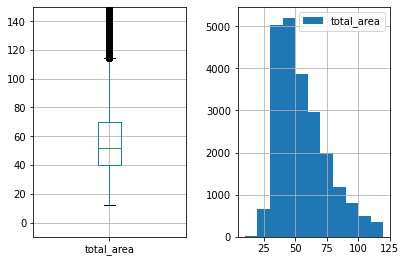

In [47]:
plt.subplot(1, 2, 1)
data.boxplot(column=['total_area'])
plt.ylim(-10, 150) 

plt.subplot(1, 2, 2)
data['total_area'].hist(range=(10,120),legend=True,bins=11)

plt.tight_layout(2)

##### Средняя (медианная) площадь объектов недвижимости в объявлениях равняется 50 квадратным метрам.

Большая часть объявлений сосредоточена в диапазоне от 30 до 100 кв. метров с небольшим пиком на отметке в 50 кв. метров.

Объявления о недвижимости с площадью до 40 кв. метров - встречаются не часто.

Чем больше площадь в объявлении, тем реже попадаются такие объявления. Объявления о недвижимости больше 120 кв. метров - крайне редки.

Распределение напоминает распределение Пуассона.

Перейдем к жилой площади.

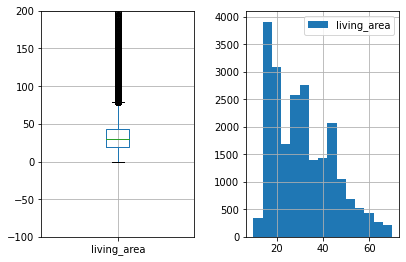

In [48]:
plt.subplot(1, 2, 1)
data.boxplot(column=['living_area'])
plt.ylim(-100, 200) 

plt.subplot(1, 2, 2)
data['living_area'].hist(range=(10,70),legend=True,bins=15)

plt.tight_layout(2)

Средняя (медианная) жилая площадь объектов недвижимости в объявлениях равняется 30 квадратным метрам.

Большая часть объявлений сосредоточена в диапазоне от 15 до 45 кв. метров. На гистограмме видно три пика через 10-15 метров каждый, что может быть обусловлено количеством комнат. Количество комнат зачастую растет с увеличением общей площади, а от количества комнат может уже зависеть жилая площадь, это вполне может объяснять дискретную природу пиков. 

Объявления о недвижимости с жилой площадью до 15 кв. метров - встречаются редко.

Чем больше жилая площадь в объявлении, тем реже попадаются такие объявления. Объявления с жилой площадью больше 70 кв. метров - крайне редки.


Перейдем к площади кухни.

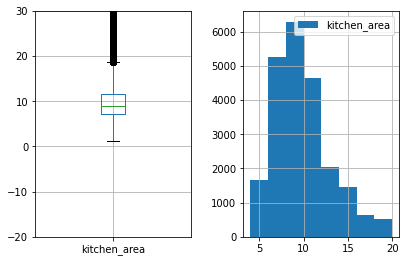

In [49]:
plt.subplot(1, 2, 1)
data.boxplot(column=['kitchen_area'])
plt.ylim(-20, 30) 

plt.subplot(1, 2, 2)
data['kitchen_area'].hist(range=(4,20),legend=True,bins=8)

plt.tight_layout(2)

Средняя (медианная) площадь кухни объектов недвижимости в объявлениях равняется 9 квадратным метрам.

Большая часть объявлений сосредоточена в диапазоне от 6 до 12 кв. метров.

Объявления о недвижимости с площадью кухни до 6 кв. метров - встречаются редко.

Чем больше площадь кухни в объявлении, тем реже попадаются такие объявления. Объявления с площадью кухни больше 20 кв. метров - крайне редки.

Распределение напоминает распределение Пуассона.

Перейдем к цене объекта.

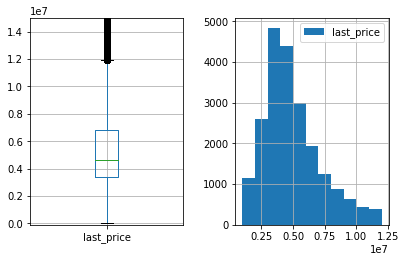

In [50]:
plt.subplot(1, 2, 1)
data.boxplot(column=['last_price'])
plt.ylim(-100000, 15000000) 

plt.subplot(1, 2, 2)
data['last_price'].hist(range=(1000000,12000000),legend=True,bins=11)

plt.tight_layout(2)

Средняя (медианная) цена объекта недвижимости в объявлениях равняется 4.65 млн. рублей.

Большая часть объявлений сосредоточена в диапазоне от 3.5 до 7 млн. рублей.

Объявления о недвижимости с ценой до 2 млн. - встречаются редко.

Чем больше цена в объявлении, тем реже попадаются такие объявления. Объявления с ценой больше 12 млн. руб. - крайне редки.

Распределение напоминает распределение Пуассона.

Перейдем к количеству комнат.

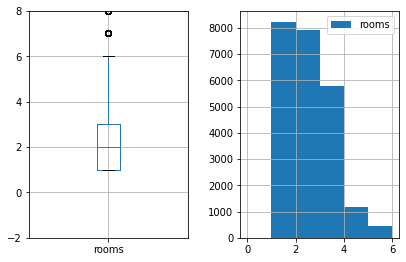

In [51]:
plt.subplot(1, 2, 1)
data.boxplot(column=['rooms'])
plt.ylim(-2, 8) 

plt.subplot(1, 2, 2)
data['rooms'].hist(range=(0,6),legend=True,bins=6)

plt.tight_layout(2)

Среднее (медианное) количество комнат у объекта недвижимости в объявлениях равняется 2.

Большая часть объявлений сосредоточена в диапазоне от 1 до 3 комнат.

Чем больше комнат у объекта в объявлении, тем реже попадаются такие объявления. Объявления с количеством комнат больше 6 - крайне редки.

Распределение напоминает распределение Пуассона.

Перейдем к высоте потолков.

Перейдем к высоте потолков.

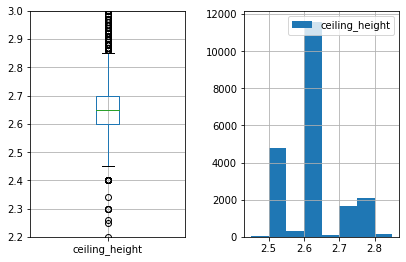

In [52]:
plt.subplot(1, 2, 1)
data.boxplot(column=['ceiling_height'])
plt.ylim(2.2, 3) 

plt.subplot(1, 2, 2)
data['ceiling_height'].hist(range=(2.45,2.85),legend=True,bins=8)

plt.tight_layout(2)

Средняя (медианная) высота потолка у объекта недвижимости в объявлениях равняется 2.65 метров.

Большая часть объявлений сосредоточена в 4 велечинах: 2,55 м., 2,65 м., 2,75 и 2,8м. Это может быть связано с наличием общепринятых стандартов в строительстве.

Чем выше потолки у объекта в объявлении, тем реже попадаются такие объявления. Объявления с высотой потолка больше 2,85 - крайне редки.


Перейдем к типу этажа квартиры.

<AxesSubplot:>

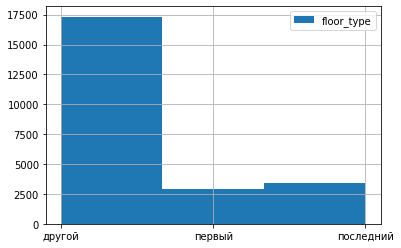

In [53]:
plt.show()
data['floor_type'].hist(legend=True,bins=3)

Объявлений с объектами на первом этаже приблизительно столько же, сколько с объектами на последнем - по 3,1 тыс. 

Объектов на других этажах приблизительно в семь рах больше, чем на первом или на последнем.

Перейдем к общему количеству этажей.

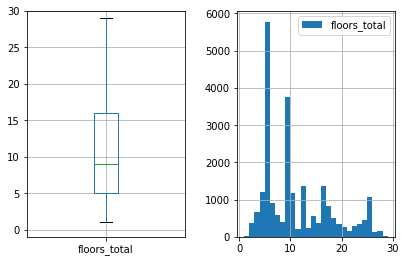

In [54]:
plt.subplot(1, 2, 1)
data.boxplot(column=['floors_total'])
plt.ylim(-1, 30) 

plt.subplot(1, 2, 2)
data['floors_total'].hist(range=(1,29),legend=True,bins=28)

plt.tight_layout(2)

Средняя (медианная) высота дома объекта недвижимости в объявлениях равняется 9 этажей.

Больше всего объявлений про объекты в домах с 5 этажами, чуть меньше с 9 этажами. Количество остальных - в 3-5 раз меньше.


Перейдем к расстоянию до центра города в метрах.

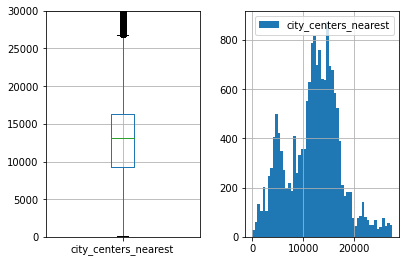

In [55]:
plt.subplot(1, 2, 1)
data.boxplot(column=['city_сenters_nearest'])
plt.ylim(0, 30000) 

plt.subplot(1, 2, 2)
data['city_сenters_nearest'].hist(range=(0,27500),legend=True,bins=55)

plt.tight_layout(2)

Среднее (медианное) расстояние до центра города по всем объектам недвижимости в объявлениях равняется порядка 13000 метров.

При этом нужно понимать, что не агрегируя по населенным пунктам расстояния, вычислять эту величину особого смысла не имеет.

Гистограмма получилась неравномерной, присутствуют пики, их наличие объяняется тем, что населенные пункты, с самым большим количеством объявлений, выдяляются на графике - каждый со своим средним расстоянием до центра.


Перейдем к расстоянию до ближайшего парка.

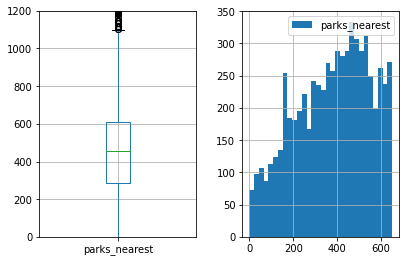

In [56]:
plt.subplot(1, 2, 1)
data.boxplot(column=['parks_nearest'])
plt.ylim(0, 1200) 

plt.subplot(1, 2, 2)
data['parks_nearest'].hist(range=(0,650),legend=True,bins=30)

plt.tight_layout(2)

##### Среднее (медианное) расстояние до ближайшего парка по всем объектам недвижимости в объявлениях равняется порядка 440 метров.

Среднее (медианное) расстояние до парка 440 м.

Чаще всего парки распологаются на расстоянии от 180 до 600 м.

Пики на графике могут быть вызваны тем, что какие-то населенные пункты имеют значительное количество объявлений и свое среднее расстояние до парка.

<a name="selling_speed"></a>
### **Изучение скорости продажи квартир**

Определим:
- сколько времени обычно занимает продажа;
- какие продажи считать быстрыми;
- какие продажи считать необычно долгими.

Для этого потребуется расчитать среднее и медиану, а также построить гистограмму и диаграмму размаха. 

Также, не забудем, что пропуски были заполнены на нули, и 0 не означает, что объявление было закрыто из-за продажи, возможно оно было не выложено или заблокировано, поэтому такие значение отбросим при рассмотрении.

In [57]:
# Вычислим среднее и медиану:
print(f"Среднее значение: {data.query('days_exposition != 0')['days_exposition'].mean():.2f}, \
медиана: {data.query('days_exposition != 0')['days_exposition'].median()}")

Среднее значение: 180.75, медиана: 95.0


Разница между средним и медианой свидетельствует о том, что бывают редкие ситуации с очень длительным сроком продажи недвижимости, хотя обычно продажа занимает порядка 95 дней.

Уточним это значение, и ответим на остальные вопросы, построив диаграмму размаха и гистограмму.

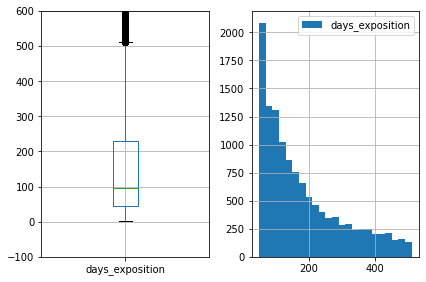

In [58]:

plt.subplot(1, 2, 1)
data.query('days_exposition != 0').boxplot(column=['days_exposition'])

plt.ylim(-100, 600) 

plt.subplot(1, 2, 2)
data.query('days_exposition != 0')['days_exposition'].hist(range=(50,510),legend=True,bins=23)

plt.tight_layout(1)

 **Вывод по скорости продажи квартир**

Теперь можно сделать вывод и ответить на поставленные вопросы.

1) Вопрос "сколько времени обычно занимает продажа" будем интепретировать как "за сколько дней большинство людей продают свои объекты недвижимости".
Половина людей укладывается в срок до 100 дней, но все-таки у большиства (75% человек - иными словами, "обычно" это занимает до 225 дней.

2) Быстрыми можно считать продажи "быстрее чем у 25% людей" - по диаграмме можно определить, что это срок до 50 дней. 

3) *Необычно* долгими можно считать продажи на границе межквартильного разамаха,  т.е. сроком порядка 500 дней. (все что больше будет считать аномалиями)

Важно отметить, что снятие объявление может и не быть связано с продажей, поэтому рекомендуется добавить процедуру отслеживания: было продано или снято по другим причинам (хотя бы в виде опроса для пользователя), это может повысить точность ответов.

<AxesSubplot:>

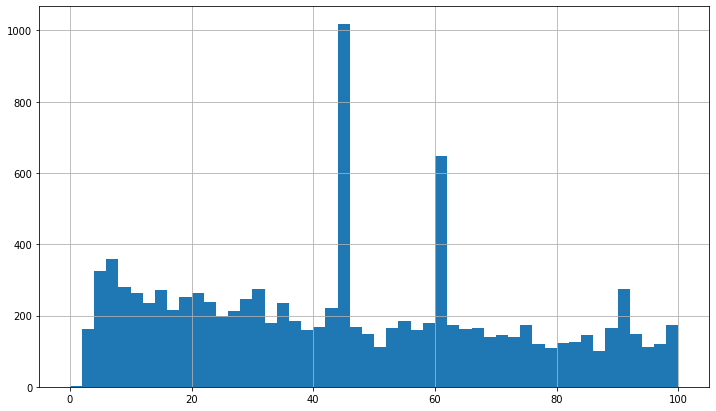

In [59]:
data['days_exposition'].hist(bins=50, range=(0,100), figsize=(12, 7))

На гистограмме действительно заметны пики примерно через 45, 60 и 90 дней после начала продажи. Можно посмотреть на условия размещения объявлений в Яндекс.Недвижимости. С учетом того, что после формирования датасета правила размещения поменялись, эти пики являются следами автоматического снятия объявлений - поэтому оценивать скорость продажи стоит действительно по диаграмме размаха

<a name="cost_total_params"></a>
### **Определение факторов, которые больше всего влияют на общую (полную) стоимость объекта**

Изучим зависимость от указанных параметров:
- общей площади;
- жилой площади;
- площади кухни;
- количества комнат;
- этажа, на котором расположена квартира (первый, последний, другой);
- даты размещения (день недели, месяц, год).

Для этого рассчитаем коэф. корреляции Пирсона для каждого (количественного) параметра. Возможно сразу проявится линейная зависимость.

Затем построим графики, чтобы посмотреть, вдруг будет заметна нелинейная зависимость. 

Исключим из рассмотрения аномально высокие значения по стоимости.

In [60]:
for serie in ['total_area','living_area', 'kitchen_area']:
    print(f"Зависимость цены от {serie} равна:\
    {data.query('last_price < 12000000')[serie].corr(data.query('last_price < 12000000')['last_price']):.2f}")

Зависимость цены от total_area равна:    0.70
Зависимость цены от living_area равна:    0.58
Зависимость цены от kitchen_area равна:    0.49


Полученный результат можно интепретировать, как "насколько отклоняется цена объекта от среднего при отклонении одного из параметров от их макслимального отклонения". 

Линейная зависимость цены от общей площади выражена сильно. 

А на остальные параметры *living_area* *kitchen_area* смотреть не актуально, они ведь зависят от *total_area (на этом предположении основывалось заполнение пропусков в них), так что эти параметры будут мультиколлинеарны и статистически не значимы. 

Возможно графики прояснят больше.

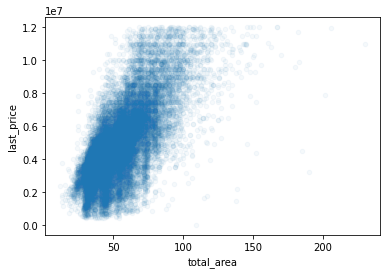

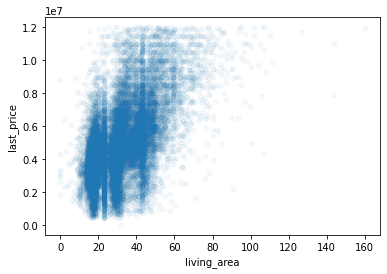

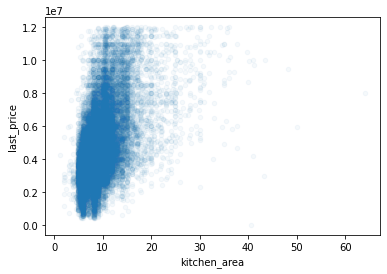

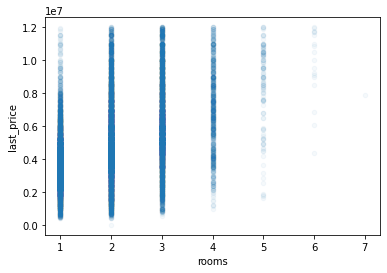

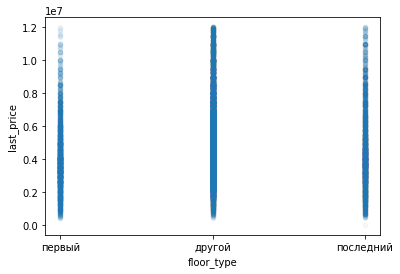

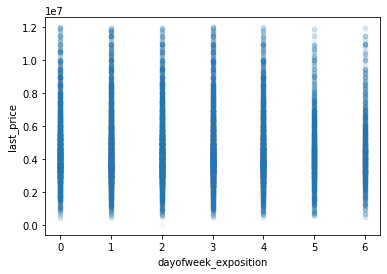

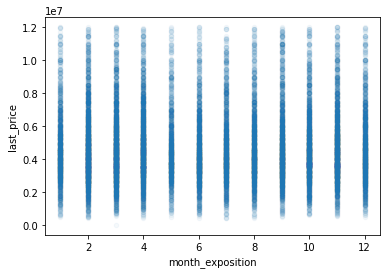

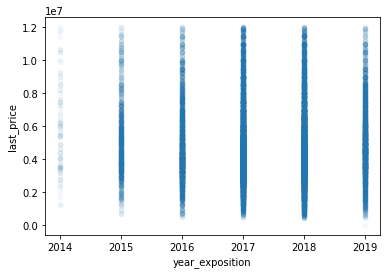

In [61]:
for serie in ['total_area',
              'living_area',
              'kitchen_area',
              'rooms',
              'floor_type',
              'dayofweek_exposition',
              'month_exposition',
              'year_exposition']:
    
    data.query('last_price < 12000000').plot(x=serie, y='last_price', kind='scatter', legend=True, alpha=0.045)


Необходимо обратить внимание на нелинейную природу зависимости стоимости от типа этажа, дня недели, месяца и года. 

Построим для них отдельные графики.

<AxesSubplot:title={'center':'Зависмость цены от типа этажа'}, xlabel='тип этажа', ylabel='цена в 10^6'>

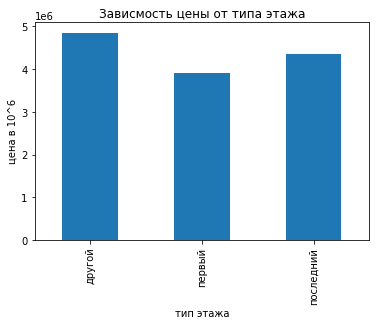

In [62]:
# Зависимость от типа этажа
data.pivot_table(index='floor_type', values='last_price', aggfunc='median').plot(kind='bar', title='Зависмость цены от типа этажа', ylabel='цена в 10^6', xlabel='тип этажа', legend=False)

<AxesSubplot:title={'center':'Цена от дня недели публикации'}, xlabel='день недели', ylabel='цена в 10^6'>

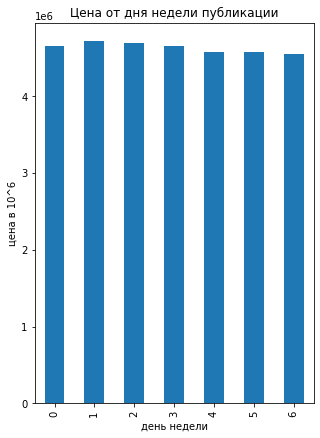

In [63]:
# Зависимость от дня недели публикаии
data.pivot_table(index='dayofweek_exposition', values='last_price', aggfunc='median').plot(kind='bar', title='Цена от дня недели публикации', ylabel='цена в 10^6', xlabel='день недели', figsize=(5,7), legend=False)

<AxesSubplot:title={'center':'Зависмость цены от месяца публикации'}, xlabel='месяц публикации', ylabel='цена в 10^6'>

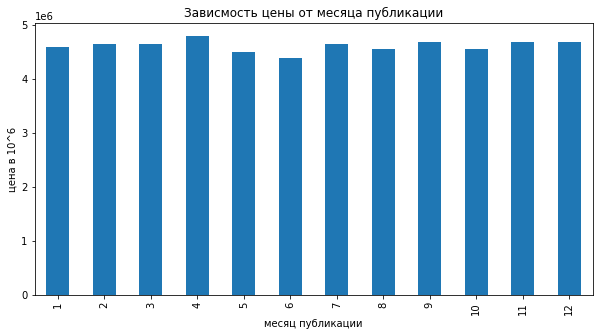

In [64]:
# Зависимость от месяца публикаии
data.pivot_table(index='month_exposition', values='last_price', aggfunc='median').plot(kind='bar', title='Зависмость цены от месяца публикации', ylabel='цена в 10^6', xlabel='месяц публикации', figsize=(10,5), legend=False)

<AxesSubplot:title={'center':'Зависмость цены от года публикации'}, xlabel='год публикации', ylabel='цена в 10^6'>

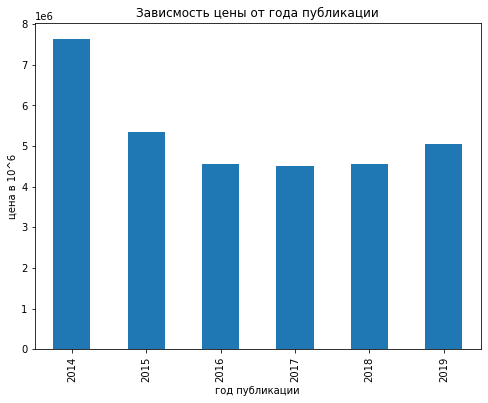

In [65]:
# Зависимость от года публикаии
data.pivot_table(index='year_exposition', values='last_price', aggfunc='median').plot(kind='bar', title='Зависмость цены от года публикации', ylabel='цена в 10^6', xlabel='год публикации', figsize=(8,6), legend=False)

Так как было установлено, что цена зависит от площади, нужно посмотреть, меняется ли по годам только цена, или изменения вызваны изменением площади продаж.

<AxesSubplot:title={'center':'Изменение средней площади продаваемого объекта по годам'}, xlabel='год публикации', ylabel='площадь объекта'>

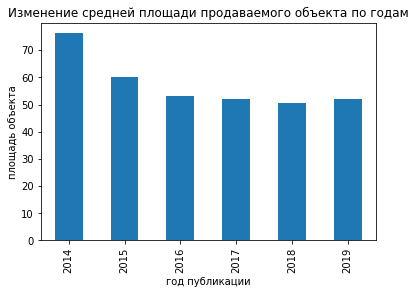

In [66]:
data.pivot_table(index='year_exposition', values='total_area', aggfunc='median').plot(kind='bar', title='Изменение средней площади продаваемого объекта по годам', xlabel='год публикации', ylabel='площадь объекта', legend=False)

**Выводы по факторам, влияющим на цену**

Можно сделать выводы по каждому из параметров:
- общая жилая площадь - есть прямая линейная зависимость, с коэф. 0.7;
- жилая площадь - статистически не значим из-за общей площади;
- площадь кухни - статистически не значим из-за общей площади;
- количество комнат - прослеживается зависимость, чем больше комнат тем больше цена (но опять же статистически не значим, количество комнат зависит от общей площади);
- этаж, на котором расположена квартира (первый, последний, другой) - на первом этаже самая дешевая нежвижимость, на последнем недвижимость стоит тоже дешевле, чем не на крайних этажах;
- дата размещения (день недели) - цена растет с понедельника по вторник и падает со среду по воскресенье
- дата размещения (месяц) - цена растет с января по апрель, падает с мая по июнь, далее с августа по октябрь держится не сиабильно, ноябрь - декабрь - стабильно высока.
- дата размещения (год) - в 2014 сервис был не популярен; после 2015 средняя цена по сделкам ниже, это обуславливается тем, что с 2015 и средняя площадь продоваемых объектов стала ниже. В 2019 средняя площадь не выросла, а цена стала стремиться к отметке 2015 года. 
Таким образом, наиболее существенное влияние на цену оказывает площадь объекта, затем тип этажа (первый, последний, другой) и дата размещения. 

Наиболее дорогая недвижимость - помещения с большой площадью, (большим количеством комнат), не на крайних этажах в апреле, (объявление выложено во вторник).

Наиболее дешевая - помещения с маленькой площадью, (одна комната), на первом этаже в июне. 

<a name="cost_per_meter"></a>
### **Расчет средней цены квадратного метра в 10 населенных пунктах, с самым большим числом объявлений**

Сначала расчитаем среднюю цену, затем выделим пункты с самой дорогой и самой дешевой ценой.

Поскольку на среднее значение сильно влияют аномалии, не будем их рассматривать.

In [67]:
# Построим сводную таблицу, исключив срезом аномальное высокие стоимости жилья, остортируем значения по убыванию
# и сохраним только первые 10 строчек.
top_ten_by_count = (data.query('last_price < 12000000')
                    .pivot_table(index='locality_name', values='cost_per_meter', aggfunc=['mean', 'count'])
                    .sort_values(by=('count','cost_per_meter'), ascending=False)
                    .head(10)
                   )
top_ten_by_count.columns = ['cost_per_meter','count']

print(top_ten_by_count)
# Сохраним крайние значения в отдельную переменную, чтобы потом использовать ее в общем выводе
most_expens_and_chop = round(top_ten_by_count['cost_per_meter'].head(1))
most_expens_and_chop = most_expens_and_chop.append(round(top_ten_by_count['cost_per_meter'].tail(1)))

print("")
print("Города с самой дорогой и самой дешевой стоимостью жилья за метр:\n",most_expens_and_chop, sep='')

                 cost_per_meter  count
locality_name                         
Санкт-Петербург   105502.327798  13796
Мурино             86087.512017    590
Кудрово            95152.072170    470
Шушары             78677.364318    440
Всеволожск         67214.252620    397
Пушкин            100322.823923    339
Колпино            75185.478244    336
Парголово          90175.913089    327
Гатчина            68421.902525    305
Выборг             57932.878771    236

Города с самой дорогой и самой дешевой стоимостью жилья за метр:
locality_name
Санкт-Петербург    105502.0
Выборг              57933.0
Name: cost_per_meter, dtype: float64


**Вывод по расчету средней цены квадратного метра**

Город с самой высокой стоимостью за метр жилья оказался Санкт-Петербург, а с самой дешевой - Выборг.

<a name="centre_cost"></a>
### **Изучение стоимости жилья в Санкт-Петербурге в зависимости от удаленности от центра**

С помощью сводной таблицы расчитаем средние цены квартир в каждом километре от центра.
Затем построим по ней график.

Поскольку на среднее значение сильно влияют аномалии, не будем их рассматривать.

In [68]:
cost_by_distance = (
       round(data
      .query('last_price < 12000000 and locality_name == "Санкт-Петербург"')
      .pivot_table(index='city_сenters_nearest_km', values='cost_per_meter')
     ))

cost_by_distance

,cost_per_meter
city_сenters_nearest_km,
0.0,119158.0
1.0,119967.0
2.0,113020.0
3.0,109024.0
4.0,113898.0
5.0,119602.0
6.0,121900.0
7.0,116834.0
8.0,115851.0


<AxesSubplot:xlabel='city_сenters_nearest_km'>

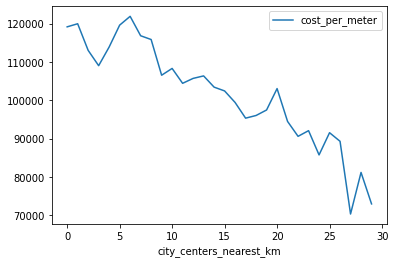

In [69]:
cost_by_distance.plot()

**Вывод по изменению стоимости жилья в Санкт-Петербурге в зависимости от удаленности от центра**

График показывает, что с увеличением расстояния от центра цена на жилье ниже.

Стоит заметить, что на графике присутствуют пики - скорее всего это обусловлено наличием в городе разных районой и жилых комплексов, стоимость жилья в которых разнится не зависимо от удаленности от центра. 

Рекомендации: можно добавить возможность указывать принадлежность объекта к жилому комплексу/району.

<a name="conclusion"></a>
## Напишите общий вывод

Первоначально была произведена предобработка данных:
- обработаны аномальные значения;
- убраны пропуски;
- изменен тип данных, где необходимо;
- устранены неявные дубликаты в названиях населенных пунктов;

По каждому пункты были предложены рекомендации по улучшению качества данных. Общие рекомендации:
- добавить ограничение для пользователя на вводимые значения (приоритетно для параметров: *количество комнат*, *высота потолков*);
- изменить способ заполнения названия населенного пункта с "ввода вручную" на "выбор по карте";
- добавить проверку - введены ли все значения;
- добавить автоматическое проставление пропусков:
1) *locality_name*, *is_apatment* - на значение по умолчанию;
2) *balcony*, *days_exposition*, *parks_around3000*, *ponds_around3000* - на нули;
- проверить есть ли лимит по дальности поиска у ПО, заполняющего данные по картографии (еслие есть,возможно, добавить категорию ('нашел/не нашел')

Затем был произведен исследовательский анализ данных.

1) Описаны наблюдения по распределению основных параметров в датасете, выявлено какие значения считать выбросами.

2) Изучено, как быстро продовались квартиры:
- у большиства (75% человек) этот процесс занимает до 225 дней, половина людей успевает продать в течение 100 дней.
- быстрыми можно считать продажи в срок до 50 дней.
- необычно долгими можно считать продажи сроком порядка 500 дней.

3) Определены факторы больше всего влияющие на стоимость квартиры:
- общая площадь (чем больше тем дороже)
- тип этажа (первый этаж - самая дешевая цена, на последнем тоже цена дешевле, чем не на крайних)
- дата размещения (день недели) - цена растет с понедельника по вторник и падает со среду по воскресенье
- дата размещения (месяц) - цена растет с января по апрель, падает с мая по июнь, далее с августа по октябрь держится не стабильно, ноябрь - декабрь - стабильно высока.
- дата размещения (год) - в 2014 сервис был не популярен; после 2015 средняя цена по сделкам ниже, это обуславливается тем, что с 2015 и средняя площадь продоваемых объектов стала ниже. В 2019 средняя площадь не выросла, а цена стала стремиться к отметке 2015 года. 

Таким образом, наиболее существенное влияние на цену оказывает площадь объекта, затем тип этажа (первый, последний, другой) и дата размещения

4) Посчитана средняя цена одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений, выделены населенные пункты с самым большим и маленьким значением.

In [70]:
print("Города с самой дорогой и самой дешевой стоимостью жилья за метр:\n",most_expens_and_chop, sep='')

Города с самой дорогой и самой дешевой стоимостью жилья за метр:
locality_name
Санкт-Петербург    105502.0
Выборг              57933.0
Name: cost_per_meter, dtype: float64


5) Описано, как стоимость объектов зависит от расстояния до центра города: чем дальше от центра - тем дешевле, но нужно брать во внимание, что цены распределены неравномерно в зависимости от района или жилого комплекса.

Подводя итог, можно составить портрет самой дорогой и самой дешевой недвижимости.

Самая дорогая - недвижимость в Санкт-Петербурге, рядом с центром в дорогом ЖК, с большой площадью (большим количеством комнат), не на крайнем этаже, в апреле, объявление выложено во вторник.

Самая дешевая - окраина Выборга, однушка с маленькой площадью на первом этаже в июне.

Чаще всего продают недвижимость от 1 до 3 комнат, чаще всего двушки. По цене от 3.5 до 7 млн., средней считается цена порядка 5 млн. Самый распространенный тип домов - пятиэтажки и девятиэтажки.  